# Synthetic 3D registration and overlap evaluation

This compact notebook verifies rigid alignment and evaluation without using hospital-linked meshes or measurements. The generated asymmetric surface has a known transform.

In [1]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np

from mesh_overlap import (
    apply_transform, evaluate_alignment, make_synthetic_pair, rigid_transform_svd,
)

## Misaligned synthetic surfaces
The source is a rotated and translated noisy copy of the target. Both arrays retain known point correspondences for this SVD demonstration.

In [2]:
pair = make_synthetic_pair(point_count=1800, noise=0.003, seed=42)
before = evaluate_alignment(pair.source, pair.target, voxel_size=0.09)
asdict(before)

{'mean_symmetric_surface_distance': 0.3035762835605623,
 'symmetric_hausdorff_distance': 0.8464997478893808,
 'voxel_dice': 0.04642857142857143,
 'voxel_jaccard': 0.02376599634369287,
 'source_voxels': 1146,
 'target_voxels': 1094,
 'intersecting_voxels': 52}

## Landmark-based rigid registration
Sixteen corresponding landmarks estimate the source-to-target rotation and translation. The complete source cloud is then transformed.

In [3]:
landmarks = np.linspace(0, len(pair.source) - 1, 16, dtype=int)
estimated = rigid_transform_svd(pair.source[landmarks], pair.target[landmarks])
aligned = apply_transform(pair.source, estimated)
after = evaluate_alignment(aligned, pair.target, voxel_size=0.09)
{
    'before mean surface distance': round(before.mean_symmetric_surface_distance, 5),
    'after mean surface distance': round(after.mean_symmetric_surface_distance, 5),
    'before voxel Dice': round(before.voxel_dice, 3),
    'after voxel Dice': round(after.voxel_dice, 3),
}

{'before mean surface distance': 0.30358,
 'after mean surface distance': 0.00498,
 'before voxel Dice': 0.046,
 'after voxel Dice': 0.95}

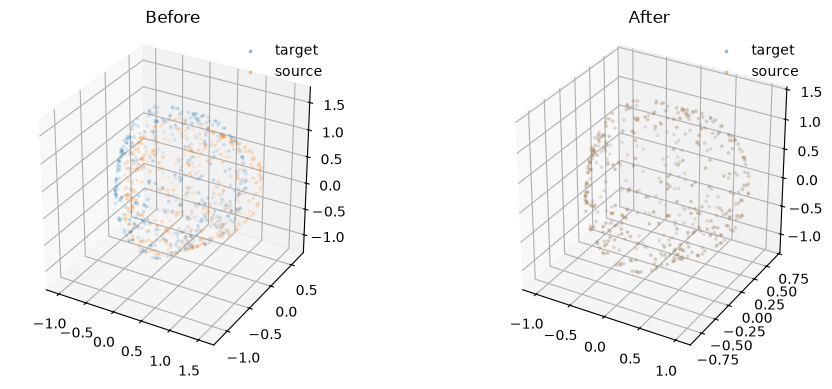

In [4]:
fig = plt.figure(figsize=(10, 4))
for position, points, title in [(1, pair.source, 'Before'), (2, aligned, 'After')]:
    axis = fig.add_subplot(1, 2, position, projection='3d')
    axis.scatter(*pair.target[::4].T, s=3, alpha=0.4, label='target')
    axis.scatter(*points[::4].T, s=3, alpha=0.4, label='source')
    axis.set_title(title)
    axis.set_box_aspect((1, 1, 1))
    axis.legend(frameon=False)
plt.tight_layout()

## Interpretation boundary
The improvement demonstrates software behaviour when correspondences are correct. It does not reproduce the original scanning-tool comparison, validate clinical use, or show that automatic registration will succeed on every geometry.